model

In [ ]:
pip install statsmodels


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.1 MB/s eta 0:00:09
   ---- ----------------------------------- 1.0/9.5 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.5 MB 1.3 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/9.5 MB 1.4 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.5 MB 1.4 MB/s eta 0:00:06
   --------- ------------------------------ 2.4/9.5 MB 1.5 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.5 MB 1.6 MB/s eta 0:00:05
   -------------- ------------------------- 3.4/9.5 MB 1.7 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.5 MB 1.8 MB/s eta 0:00:04
   ----------------- ---------------------- 4.2/9.5 MB 1.8 MB/s eta 0:00:03
   ------------------- ----------


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Load & Prepare Data

Train-Test Split
train_size = int(len(series) * 0.8)
80% → training data
20% → testing data


Build ARIMA Model
model = ARIMA(train, order=(5,1,0))



What (5,1,0) means:
p = 5 → uses last 5 lag values
d = 1 → differencing (to make data stationary)
q = 0 → no moving average part



Forecast
forecast = model_fit.forecast(steps=len(test))

=> RMSE (Root Mean Squared Error)
Penalizes large errors more
=> MAE (Mean Absolute Error)
Average absolute difference
=> MAPE (Mean Absolute Percentage Error)
Error in percentage → easy to understand




After performing exploratory analysis and feature engineering, I implemented an ARIMA model for time-series forecasting.
I split the data into training and testing sets, trained the model on historical prices, and generated forecasts.
Then I evaluated performance using RMSE, MAE, and MAPE, and visualized the results to compare predicted vs actual prices

In [6]:
pip install tensorflow

   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 1.3/350.9 MB 8.4 MB/s eta 0:00:42
   ---------------------------------------- 2.4/350.9 MB 6.7 MB/s eta 0:00:52
   ---------------------------------------- 2.9/350.9 MB 5.6 MB/s eta 0:01:03
   ---------------------------------------- 3.7/350.9 MB 5.1 MB/s eta 0:01:09
   ---------------------------------------- 4.2/350.9 MB 4.2 MB/s eta 0:01:23
   ---------------------------------------- 4.2/350.9 MB 4.2 MB/s eta 0:01:23
    --------------------------------------- 4.5/350.9 MB 3.5 MB/s eta 0:01:39
    --------------------------------------- 4.7/350.9 MB 3.2 MB/s eta 0:01:50
    --------------------------------------- 5.0/350.9 MB 3.0 MB/s eta 0:01:57
    --------------------------------------- 5.5/350.9 MB 2.7 MB/s eta 0:02:09
    --------------------------------------- 5.8/350.9 MB 2.6 MB/s eta 0:02:14
    --------------------------------------- 6.3/350.9 MB 2.5 MB/s eta 0


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Train size: 16, Test size: 4

📊 Evaluation Metrics:
RMSE: 94.47
MAE : 91.55
MAPE: nan%


c:\Users\skitd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\skitd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\skitd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\skitd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is ava

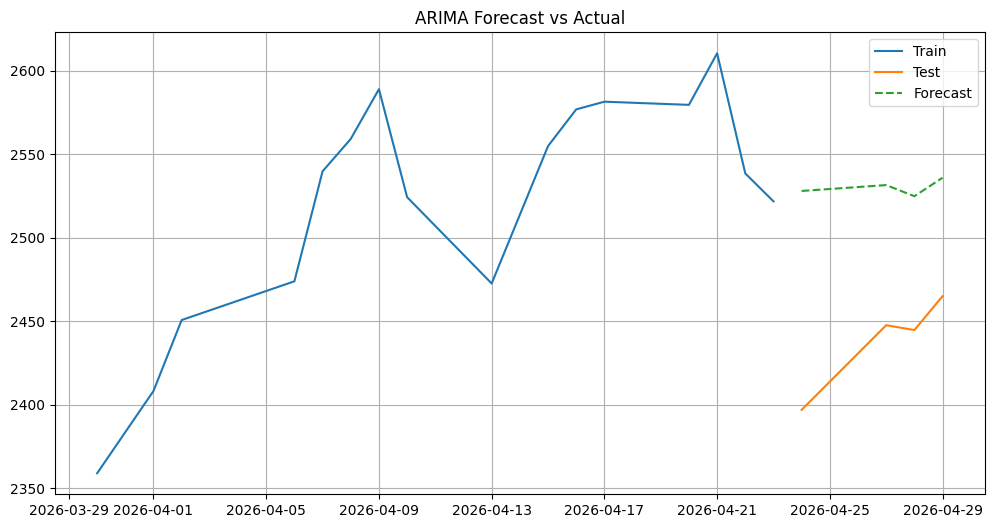

In [3]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 1. LOAD DATA (single stock for now)
# ─────────────────────────────────────────────
file_path = r"E:\KEC TASK\Download data\TCS Historical Data.csv"

df = pd.read_csv(file_path)
df.columns = [c.strip().strip('"') for c in df.columns]

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date")

df["Price"] = df["Price"].astype(str).str.replace(",", "").astype(float)

df.set_index("Date", inplace=True)

series = df["Price"]

# ─────────────────────────────────────────────
# 2. TRAIN-TEST SPLIT
# ─────────────────────────────────────────────
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}")

# ─────────────────────────────────────────────
# 3. BUILD ARIMA MODEL
# ─────────────────────────────────────────────
model = ARIMA(train, order=(5,1,0))   # (p,d,q)
model_fit = model.fit()

# ─────────────────────────────────────────────
# 4. FORECAST
# ─────────────────────────────────────────────
forecast = model_fit.forecast(steps=len(test))

# ─────────────────────────────────────────────
# 5. EVALUATION METRICS
# ─────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("\n📊 Evaluation Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# ─────────────────────────────────────────────
# 6. PLOT RESULTS
# ─────────────────────────────────────────────
plt.figure(figsize=(12,6))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Forecast", linestyle="--")

plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.grid()
plt.show()

Load & Clean Data



Feature Engineering


df["lag_1"] = df["Price"].shift(1)
df["lag_2"] = df["Price"].shift(2)
df["lag_3"] = df["Price"].shift(3)


Yesterday’s price → lag_1
2 days ago → lag_2
3 days ago → lag_3


Train-Test Split (Time-Based)

80% → training
20% → testing


Train Model (Random Forest)

model = RandomForestRegressor(n_estimators=100)

Visualization
Actual prices vs predicted prices


What This Script Achieves

| ARIMA               | Random Forest                |
| ------------------- | ---------------------------- |
| Statistical model   | ML model                     |
| Linear assumptions  | Captures non-linear patterns |
| Uses past structure | Uses engineered features     |







📊 Random Forest Metrics:
RMSE: 94.10
MAE : 87.59
MAPE: 3.61%


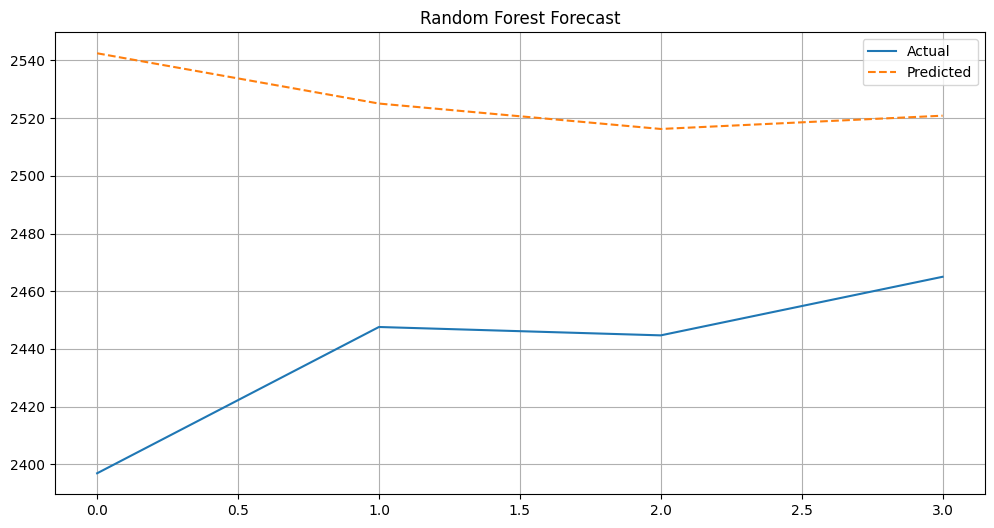

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
file_path = r"E:\KEC TASK\Download data\TCS Historical Data.csv"

df = pd.read_csv(file_path)
df.columns = [c.strip().strip('"') for c in df.columns]

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date")

df["Price"] = df["Price"].astype(str).str.replace(",", "").astype(float)

# ─────────────────────────────────────────────
# 2. CREATE FEATURES (LAG FEATURES)
# ─────────────────────────────────────────────
df["lag_1"] = df["Price"].shift(1)
df["lag_2"] = df["Price"].shift(2)
df["lag_3"] = df["Price"].shift(3)

df = df.dropna()

X = df[["lag_1", "lag_2", "lag_3"]]
y = df["Price"]

# ─────────────────────────────────────────────
# 3. TRAIN-TEST SPLIT (TIME BASED)
# ─────────────────────────────────────────────
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]

# ─────────────────────────────────────────────
# 4. MODEL TRAINING
# ─────────────────────────────────────────────
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ─────────────────────────────────────────────
# 5. PREDICTION
# ─────────────────────────────────────────────
predictions = model.predict(X_test)

# ─────────────────────────────────────────────
# 6. EVALUATION
# ─────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print("\n📊 Random Forest Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# ─────────────────────────────────────────────
# 7. PLOT
# ─────────────────────────────────────────────
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted", linestyle="--")

plt.title("Random Forest Forecast")
plt.legend()
plt.grid()
plt.show()

Epoch 1/10


c:\Users\skitd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.6505
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.5987
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5495
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.5027
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.4582
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.4160
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.3758
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.3376
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.3013
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.2670
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step

📊 LSTM Metrics:
RMSE: 24.65
MAE : 21.65
MAPE: 0.88%


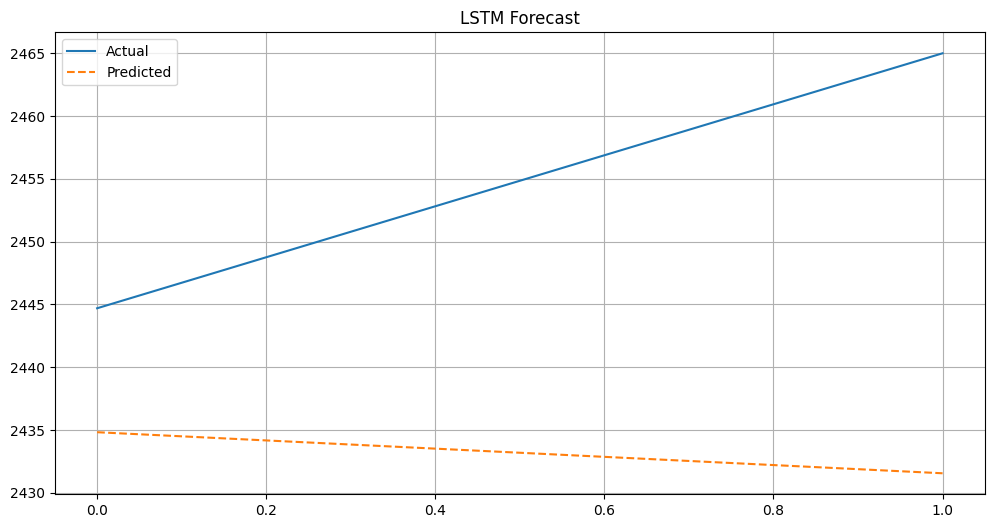

LSTM neural network to capture sequential patterns in stock prices and predict future values.



LSTM requires scaled data, so I used MinMaxScaler.


Creates Sequences
Last 10 days → predict next day



Learns Patterns Using LSTM

Remembers past trends
Understands sequence behavior
Handles long-term dependencies





Unlike:

ARIMA → linear
Random Forest → static features

👉 LSTM:

“Understands time flow + memory”



Predicts Future Prices
Takes last sequence
Predicts next value

Epoch 1/20


c:\Users\skitd\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.5174
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.4573
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.4025
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.3527
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.3077
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.2674
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2315
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1999
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1725
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1493
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1302
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1154
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1049
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0986
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0962
Epoch 16/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/st

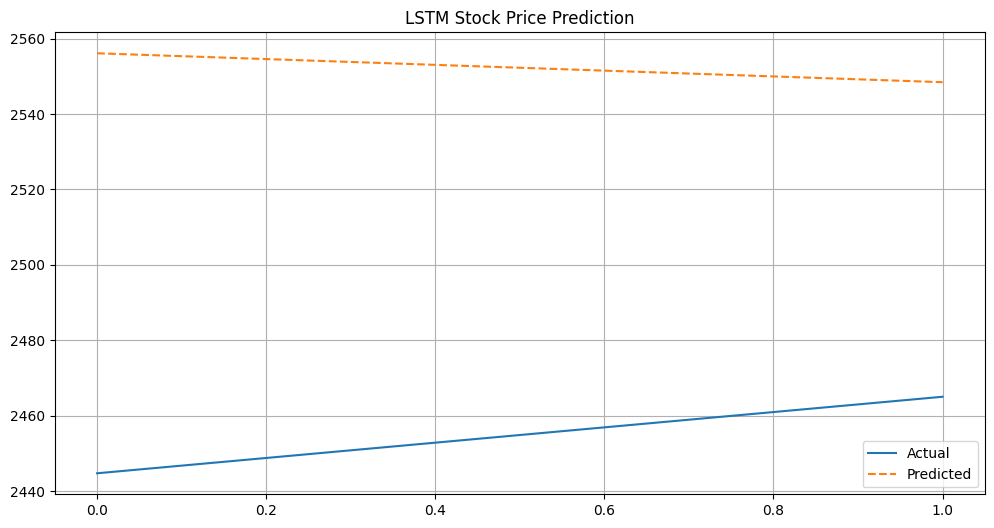

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
file_path = r"E:\KEC TASK\Download data\TCS Historical Data.csv"

df = pd.read_csv(file_path)
df.columns = [c.strip().strip('"') for c in df.columns]

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date")

df["Price"] = df["Price"].astype(str).str.replace(",", "").astype(float)

data = df[["Price"]].values

# ─────────────────────────────────────────────
# 2. NORMALIZE DATA (VERY IMPORTANT FOR LSTM)
# ─────────────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# ─────────────────────────────────────────────
# 3. CREATE SEQUENCES
# ─────────────────────────────────────────────
def create_sequences(data, window_size=10):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 10
X, y = create_sequences(scaled_data, window_size)

# reshape for LSTM → (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

# ─────────────────────────────────────────────
# 4. TRAIN-TEST SPLIT
# ─────────────────────────────────────────────
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# ─────────────────────────────────────────────
# 5. BUILD LSTM MODEL
# ─────────────────────────────────────────────
model = Sequential()

model.add(LSTM(units=50, return_sequences=False, input_shape=(X.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# ─────────────────────────────────────────────
# 6. TRAIN MODEL
# ─────────────────────────────────────────────
model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=1)

# ─────────────────────────────────────────────
# 7. PREDICTIONS
# ─────────────────────────────────────────────
predictions = model.predict(X_test)

# inverse scaling
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# ─────────────────────────────────────────────
# 8. EVALUATION
# ─────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print("\n📊 LSTM Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# ─────────────────────────────────────────────
# 9. PLOT
# ─────────────────────────────────────────────
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted", linestyle="--")

plt.title("LSTM Stock Price Prediction")
plt.legend()
plt.grid()
plt.show()